In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("../data/processed/ecommerce_master_dataset.csv")

In [14]:
rfm_df = df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "payment_value": "sum"
}).reset_index()

In [15]:
rfm_df.columns = ["customer_id", "last_purchase_date", "frequency", "monetary"]

In [23]:
rfm_df.head()

,customer_id,last_purchase_date,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,163
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,585
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,369
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,336


In [20]:
rfm_df["last_purchase_date"] = pd.to_datetime(rfm_df["last_purchase_date"])

In [21]:
snapshot_date = pd.to_datetime(snapshot_date)

In [22]:
rfm_df["recency"] = (snapshot_date - rfm_df["last_purchase_date"]).dt.days

In [24]:
rfm_df["R_score"] = pd.qcut(rfm_df["recency"], 4, labels=[4,3,2,1])
rfm_df["F_score"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm_df["M_score"] = pd.qcut(rfm_df["monetary"], 4, labels=[1,2,3,4])

In [25]:
rfm_df["RFM_segment"] = (
    rfm_df["R_score"].astype(str)
    + rfm_df["F_score"].astype(str)
    + rfm_df["M_score"].astype(str)
)

In [26]:
rfm_df.head()

,customer_id,last_purchase_date,frequency,monetary,recency,R_score,F_score,M_score,RFM_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,160,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,163,4,1,1,411
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,585,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,369,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,336,2,1,3,213


In [27]:
def segment_customer(row):
    if row["R_score"] == 4 and row["F_score"] == 4:
        return "Champions"
    elif row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] == 1:
        return "At Risk"
    else:
        return "Regular Customers"

rfm_df["customer_segment"] = rfm_df.apply(segment_customer, axis=1)

In [28]:
rfm_df["customer_segment"].value_counts()

customer_segment
Loyal Customers      41908
Regular Customers    35917
At Risk              12131
Champions             6140
Name: count, dtype: int64

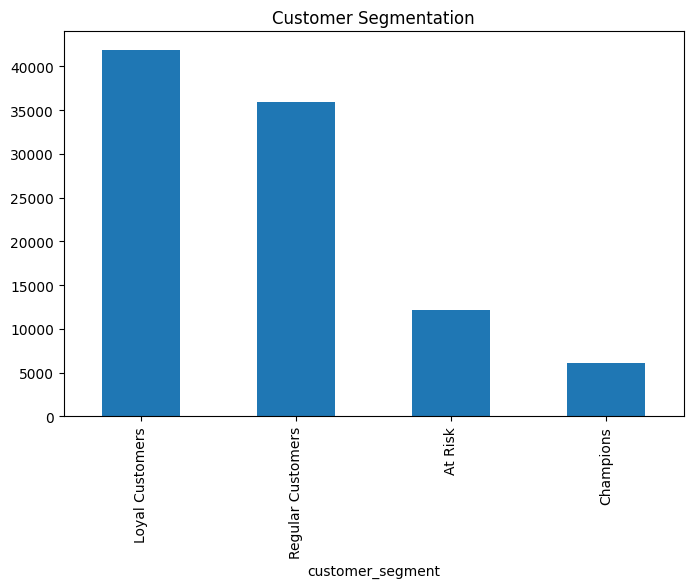

In [29]:
rfm_df["customer_segment"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Customer Segmentation")
plt.show()